# AG-HYPOPT · Trial 13

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twelve trials recorded, objective order: trial_09 0.1657 (BEST), trial_05 0.1863, trial_11 0.1883, trial_01 0.1907, trial_07 0.1940, trial_12 0.1941, trial_08 0.1948, trial_04 0.1987, trial_02 0.2075, trial_06 0.2203, trial_03 0.2472, trial_10 0.3727 (worst). Recap: mu_fit is pinned at ~half of mu_true for every config (objective floor); the objective is the gamma term, dominated by low transmission, and it is highly unstable. The best region observed is high sigma_ref (~21-25), high lr_gamma (~0.86-0.91), low-to-mid lr_mu and moderate-to-strong anneal (~0.41-0.6); trial_09 added a partly-rescued Trans05. TPE (12/5) is exploiting. Context only.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_13'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (12/5 trials)
ID |     ei | params
 1 | 0.4645 | {"gamma_anneal": 0.15823888144421355, "lr_gamma": 0.9630175970855667, "lr_mu": 28.661644511151582, "sigma_ref": 10.87332343112461}
 2 | 3.0113 | {"gamma_anneal": 0.42641304935381374, "lr_gamma": 0.8713183082487955, "lr_mu": 15.957001182585536, "sigma_ref": 21.62120797233693}
 3 | 2.3529 | {"gamma_anneal": 0.4659312711115826, "lr_gamma": 0.8213489248006949, "lr_mu": 10.181560388879381, "sigma_ref": 18.332673990723656}
 4 | 2.0568 | {"gamma_anneal": 0.4492332392750784, "lr_gamma": 1.0, "lr_mu": 18.75570972458432, "sigma_ref": 11.82416363015243}
 5 | 1.0534 | {"gamma_anneal": 0.542304540397198, "lr_gamma": 0.8720219112546604, "lr_mu": 28.961707985316178, "sigma_ref": 5.0}
 6 | 0.4413 | {"gamma_anneal": 0.49315665089012434, "lr_gamma": 0.6836639104298754, "lr_mu": 13.830450697673658, "sigma_ref": 7.074825610643411}
 7 | 3.2502 | {"gamma_anneal": 0.4011602314470213, "lr_gamma": 0.8571273078630519, "lr_mu": 18.986613390263727, 

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

TPE (12/5) ranks by expected improvement. The highest-EI candidate is candidate 7 (EI 3.25): gamma_anneal 0.401, lr_gamma 0.857, lr_mu 18.99, sigma_ref 24.83 -- high sigma_ref (in the best-trial band), high lr_gamma and moderate anneal, but with the higher lr_mu that has landed mid-pack in trials 12 and 06. The runner-up candidate 8 (EI 3.12) is closer to the trial_09 recipe (lr_mu 9.92, lr_gamma 0.986) but at a low sigma_ref 8.93; candidate 2 (EI 3.01) sits between them. The top-EI pick is squarely in the good high-sigma_ref / high-lr_gamma region, so I follow it. I choose candidate 7.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 7               # highest-EI TPE pick (high-sigma_ref region)


chosen: {'gamma_anneal': 0.4011602314470213, 'lr_gamma': 0.8571273078630519, 'lr_mu': 18.986613390263727, 'sigma_ref': 24.829891944165983}
Running  1nW Trans05 ... 

μ 9.39 -> 4.72 | γ 8.5 -> 3.38 | NLL 1.29


Running  1nW Trans20 ... 

μ 17.32 -> 8.67 | γ 8.5 -> 4.03 | NLL 3.05


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 50.68 | γ 14.1 -> 13.66 | NLL 3.08


Running 3nW Trans100 ... 

μ 175.71 -> 85.47 | γ 14.1 -> 13.69 | NLL 2.97



Total: 2.4 min


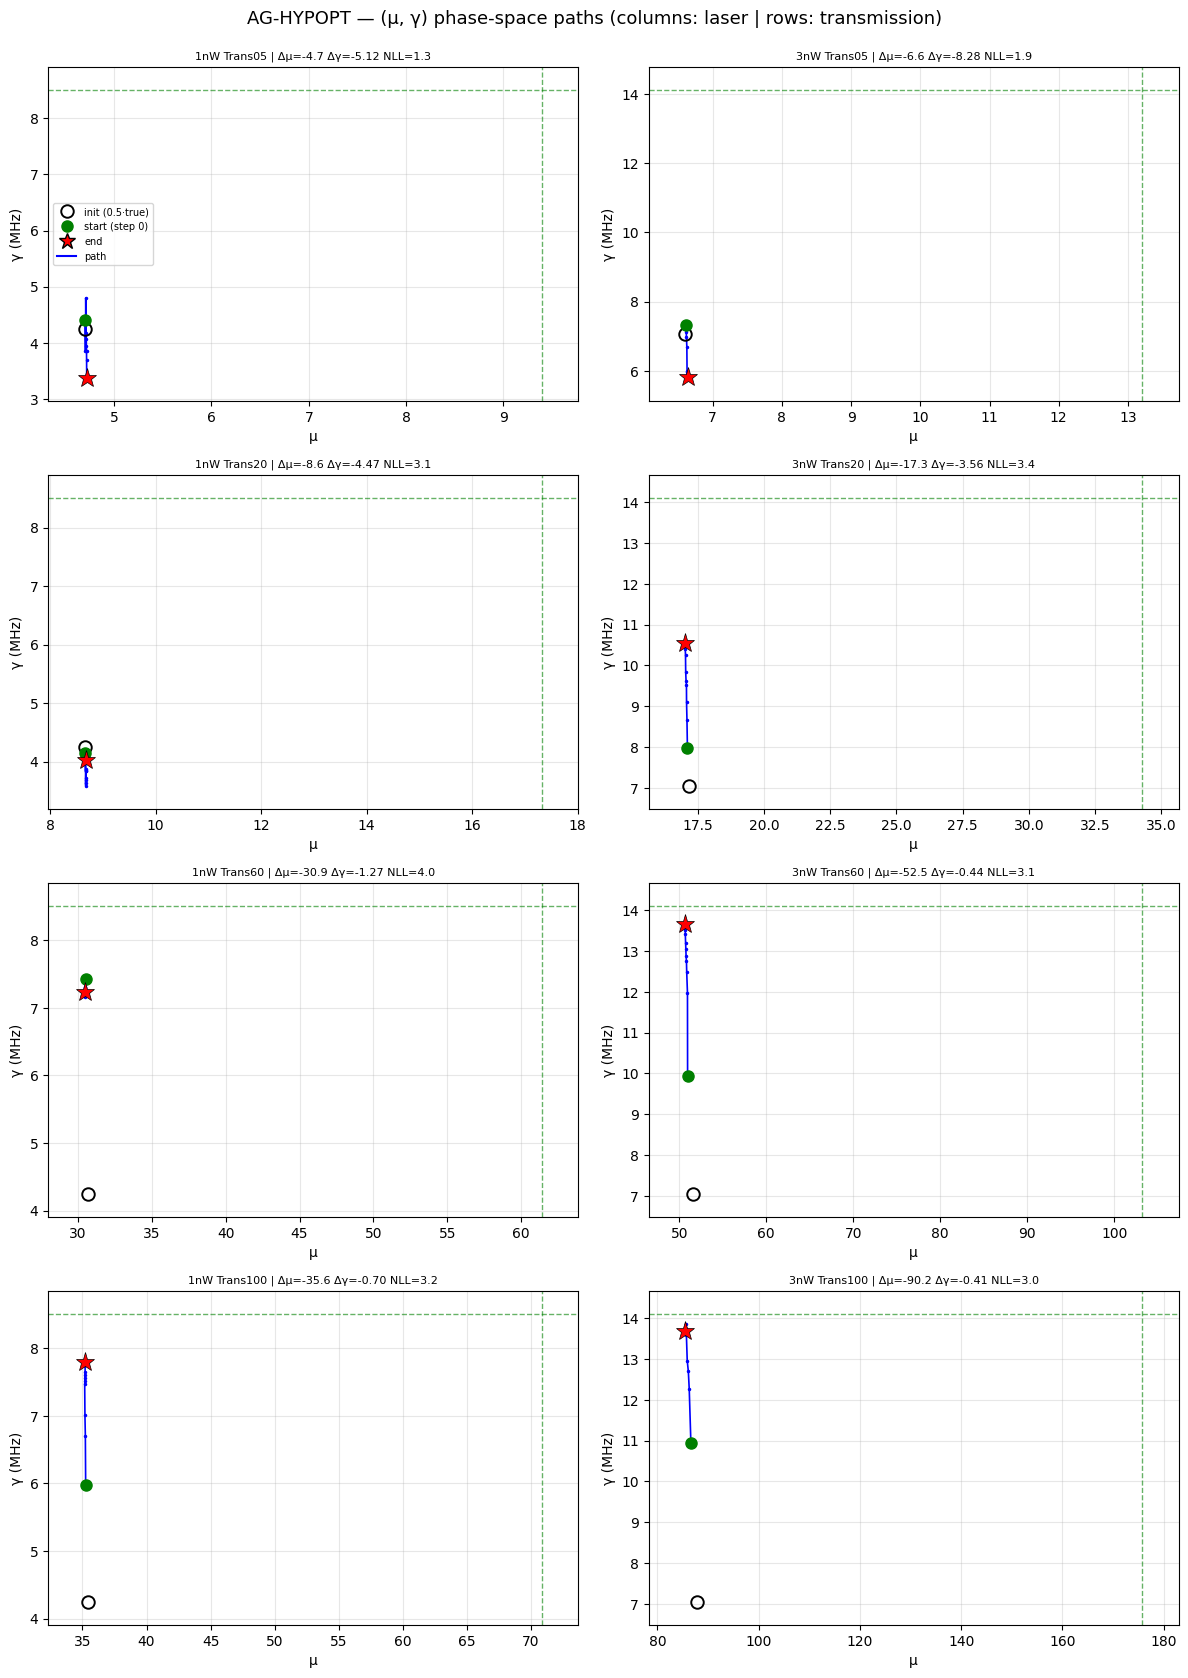

trial finished in 2.4 min
objective = 0.1941 ± 0.0318
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    4.72   -49.8 |     8.50    3.38   -60.3
1nW Trans20    17.32    8.67   -49.9 |     8.50    4.03   -52.6
1nW Trans60    61.37   30.46   -50.4 |     8.50    7.23   -14.9
1nW Trans100   70.82   35.21   -50.3 |     8.50    7.80    -8.2
3nW Trans05    13.20    6.64   -49.7 |    14.10    5.82   -58.7
3nW Trans20    34.28   17.01   -50.4 |    14.10   10.54   -25.2
3nW Trans60   103.20   50.68   -50.9 |    14.10   13.66    -3.1
3nW Trans100  175.71   85.47   -51.4 |    14.10   13.69    -2.9

μ: RMSE 41.173 (rel 50.3%, bias -30.803) | γ: RMSE 4.030 (rel 36.7%, bias -3.031)


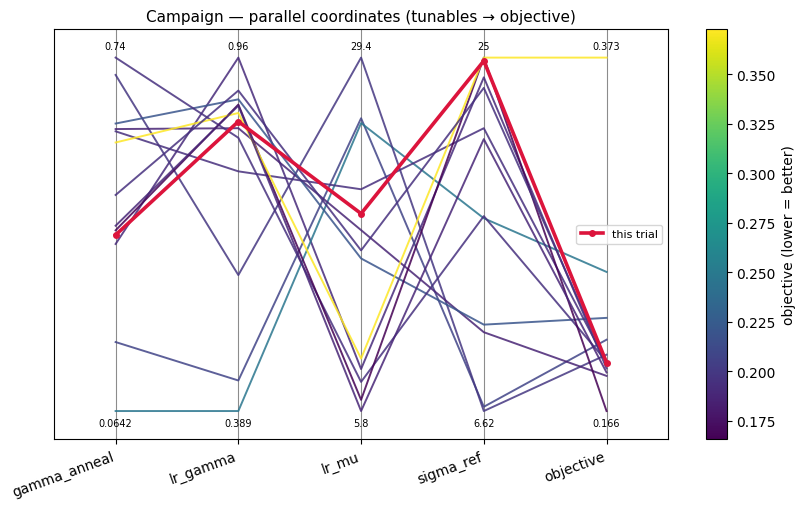

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 13, eighth TPE-driven trial; highest-EI pick: sigma_ref 24.83, lr_mu 18.99, lr_gamma 0.857, gamma_anneal 0.401. Result: objective 0.1941 +/- 0.0318, essentially identical to trial_12 (0.1941) and trial_07 (0.1940) -- a stable mid-pack level; runtime 2.4 min. mu_fit is unchanged at a uniform ~half-truth (Delta-mu% -49.7 to -51.4; mu RMSE 41.17, relative 50.3%). gamma_fit: high/mid transmission good-to-fair (3 nW Trans60/100: -3.1/-2.9%; 1 nW Trans100 -8.2%) but low transmission still degraded (1 nW Trans05 -60.3%, 1 nW Trans20 -52.6%; 3 nW Trans05 -58.7%), gamma RMSE 4.03 (relative 36.7%). This is now the third near-replicate of the ~0.194 mid-pack plateau (trials 07, 12, 13).

**Summary:** Trial 13 (sigma_ref 24.83, lr_mu 18.99, lr_gamma 0.857, gamma_anneal 0.401) -> objective 0.1941 +/- 0.0318, a third near-replicate of the ~0.194 mid-pack plateau (with trials 07, 12); Trans05/20 gamma still degraded.
**Key insight:** A whole band of high-sigma_ref / high-lr_gamma configs reproduces a stable ~0.194 plateau, well above the 0.1657 best -- so the single best trial_09 looks like a lucky draw in an unstable low-transmission gamma regime rather than a reproducible optimum.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
No new structural notes; the real-data attractor note from trial_01 still stands.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 13 (sigma_ref 24.83, lr_mu 18.99, lr_gamma 0.857, gamma_anneal 0.401): objective 0.1941 +/- 0.0318, a third near-replicate of the ~0.194 mid-pack plateau (trials 07, 12); Trans05/20 gamma still degraded'
KEY_INSIGHT = 'A broad band of high-sigma_ref / high-lr_gamma configs reproduces a stable ~0.194 plateau far above the 0.1657 best -- the trial_09 win looks like a lucky draw in an unstable low-transmission gamma regime, not a reproducible optimum.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_13 | current best: trial_09


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_14.ipynb. Open it and follow its cells from the top.
